<a href="https://colab.research.google.com/github/nebojsa-bozanic/BMI_OSuM/blob/dev/00_osnovne_manipulacije.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Obrada slike u medicini (BMI)

Literatura: https://moodle.telekom.ftn.uns.ac.rs/course/view.php?id=82


## Laboratorijska vežba 1: Osnovne manipulacije

Potrebne biblioteke: cv2, numpy, matplotlib.pyplot, pydicom

In [1]:
!git clone https://github.com/nebojsa-bozanic/BMI_OSuM.git
%cd /content/BMI_OSuM

Cloning into 'BMI_OSuM'...
remote: Enumerating objects: 965, done.
remote: Counting objects: 100% (205/205), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 965 (delta 154), reused 101 (delta 101), pack-reused 760 (from 1)
Receiving objects: 100% (965/965), 244.43 MiB | 36.85 MiB/s, done.
Resolving deltas: 100% (413/413), done.
/content/BMI_OSuM


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

from google.colab.patches import cv2_imshow

### 1. Učitavanje, prikaz i snimanje slike

1.1. U promenljivu im1 učitati sliku mr_glava_1.jpg u odgovarajućem režimu za sliku u sivoj skali.

In [3]:
!gdown "https://drive.google.com/uc?id=1jJGGYGhnUGVHkLangj17KaVF5U1XyUGi"

Downloading...
From: https://drive.google.com/uc?id=1jJGGYGhnUGVHkLangj17KaVF5U1XyUGi
To: /content/BMI_OSuM/mr_glava_1.jpg
100% 29.8k/29.8k [00:00<00:00, 88.9MB/s]


In [4]:
im1 = cv2.imread('mr_glava_1.jpg', cv2.IMREAD_GRAYSCALE) # ukoliko slika nije u ovom folderu ovde staviti putanju do nje
# IMREAD_GRAYSCALE - siva slika uint8 tipa

1.2. Sliku im1 prikazati koristeći funkcije iz cv2 biblioteke.

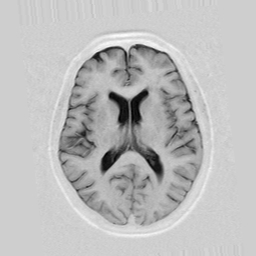

In [5]:
cv2_imshow(im1) # 'Slika 1',

1.3. Sliku im1 prikazati koristeći funkcije iz matplotlib.pyplot biblioteke.

Text(0.5, 1.0, 'Slika 1')

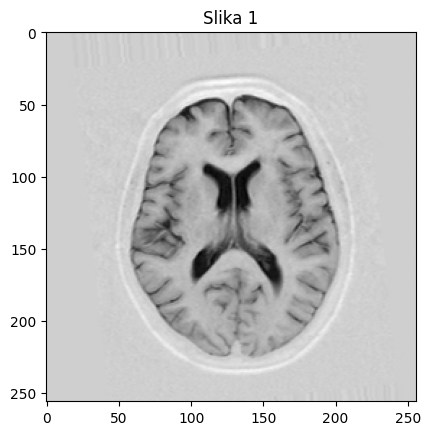

In [6]:
plt.figure(1)
plt.imshow(im1, cmap='gray')
plt.title('Slika 1')

1.4. Napraviti sliku im2 indeksiranjem slike im1. Iz im1 iseći piksele [100:200, :]. Koliko vrsta ima slika im2?

In [7]:
im2 = im1[100:200, :]

1.5. Sačuvati sliku im2 pod nazivom mr1_crop.jpg.

In [8]:
cv2.imwrite('mr1_crop.jpg', im2)

True

### 2. Tipovi podataka i dubina sive skale

Dva osnovna tipa podataka kojima su predstavljeni pikseli slike:
1. float – može da prikaže decimalne vrednosti
2. integer – celobrojne vrednosti
  Znak: unsigned (uint) – prikazuje nenegativne vrednosti
  signed (int) – prikazuje i negativne vrednosti
  Veličina: 8, 16, 32… - broj bita kojim je predstavljen jedna piksel

2.1. U promenljivu im3 učitati sliku rtg_2.png. U pitanju je uint16 slika, pa je potrebno izabrati odgovarajući režim.


In [9]:
im3 = cv2.imread('rtg_2.png', cv2.IMREAD_ANYDEPTH) # rezim koji ucitava sivu sliku proizvoljnog tipa
print(im3)

None


2.2. Koja je dubina sive skale uint8, int8, a koja uint16 tipa?

2.3. Prikazati sliku im3 vodeći računa o granicama dinamičkog opsega.

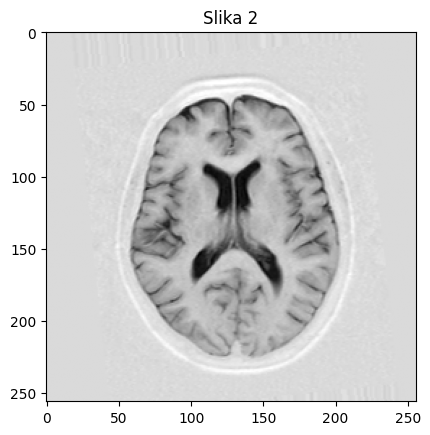

In [10]:
plt.figure()
plt.imshow(im1, cmap='gray', vmin=im2.min(), vmax=im2.max()) # pun opseg: vmin=0, vmax=65535
plt.title('Slika 2')
plt.show()

### 3. Slika razlika


3.1. U promenljivu im4 učitati sliku mr_glava_2.jpg u režimu za sliku u sivoj skali.

In [11]:
!gdown "https://drive.google.com/uc?id=1T9A7NIsfhdPADdwJF3NDNvNl6v9FOMNa"

Downloading...
From: https://drive.google.com/uc?id=1T9A7NIsfhdPADdwJF3NDNvNl6v9FOMNa
To: /content/BMI_OSuM/mr_glava_2.jpg
100% 31.8k/31.8k [00:00<00:00, 54.4MB/s]


In [12]:
im4 = cv2.imread('mr_glava_2.jpg', cv2.IMREAD_GRAYSCALE)

3.2. Napraviti sliku razlika im_r1 oduzimanjem im1 i im4. Analizirati vrednosti piksela te slike. Da li su dobijene vrednosti tačne?

In [13]:
im_r1 = im1-im4

3.3. Promeniti tip slika im1 i im4 u int16 (ili neki drugi kojim mogu da se zapišu negativne vrednosti i odgovarajući opseg) i napraviti sliku razlika im_r2. Koje su sada vrednosti piksela?

In [14]:
im_r2 = im1.astype(np.int16)-im4.astype(np.int16)

3.4. Prikazati sliku im_r2. Definisati granice dinamičkog opsega za prikaz.

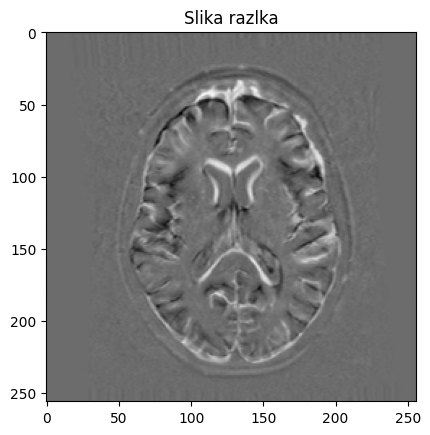

In [15]:
plt.figure()
plt.imshow(im_r2, cmap='gray', vmin=im_r2.min(), vmax=im_r2.max())
plt.title('Slika razlka')
plt.show()

3.5. Napraviti sliku apsolutnih razlika im_r3 i prikazati je. Kako se razlikuju slike im_r2 i im_r3?

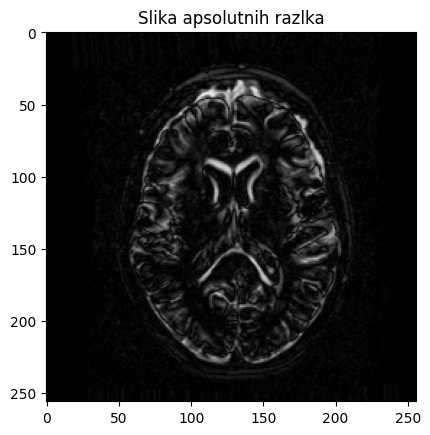

In [16]:
im_r3 = abs(im1.astype(np.int16)-im4.astype(np.int16))
plt.figure()
plt.imshow(im_r3, cmap='gray', vmin=im_r3.min(), vmax=im_r3.max())
plt.title('Slika apsolutnih razlka')
plt.show()

3.6. Napraviti sliku im_n normalizaijom vrednosti im_r3 na opseg [0, 1]. Kog tipa je ova slika? Prikazati sliku.

float64


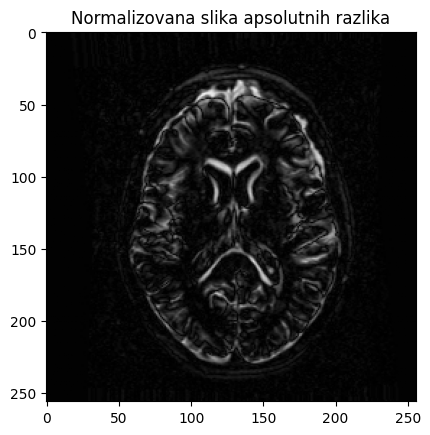

In [17]:
im_n = (im_r3-im_r3.min())/(im_r3.max()-im_r3.min())
print(im_n.dtype)
plt.title('Normalizovana slika apsolutnih razlika')
plt.imshow(im_n, cmap='gray')

### 4. Matematičke operacije

4.1. Napraviti sliku im1_2 dodavanjem vrednosti 200 na svaki piksel im1. Voditi računa o opsegu vrednosti nove slike pa u skladu sa tim izabrati odgovarajući tip.


In [18]:
im1_2 = im1.astype(np.int16)+200

4.2. Napraviti sliku im1_3 oduzimanjem vrednosti 200 od svakog piksela slike im1. Voditi računa o opsegu vrednosti nove slike pa u skladu sa tim izabrati odgovarajući tip.

In [19]:
im1_3 = im1.astype(np.int16)-200

4.3. U jednom prozoru prikazati sliku im1, im2 i im3. Izabrati granice dinamičkog opsega za prikaz tako da je moguće uporediti ove slike. Kakav je efekat povećanja, a kakav smanjenja vrednosti piksela?

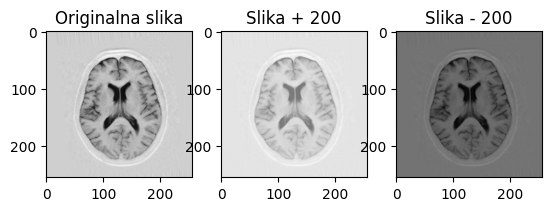

In [20]:
fig, axs = plt.subplots(1, 3)
axs[0].imshow(im1, cmap='gray')
axs[0].set_title('Originalna slika')
axs[1].imshow(im1_2, cmap='gray', vmin=0, vmax=im1_2.max())
axs[1].set_title('Slika + 200')
axs[2].imshow(im1_3, cmap='gray', vmin=im1_3.min(), vmax=255)
axs[2].set_title('Slika - 200')
plt.show()

4.4. Sliku im1 skalirati množenjem sa 3.5 i deljenjem sa 1.5. Koji su efekti?

In [21]:
im1_4 = im1*3.5
im1_5 = im1/1.5

### 5. Osnovne statistike slike

5.1. Odrediti minimum i maksimum slike im1. Koji je opseg slike?

In [22]:
im1_min = im1.min()
im1_max = im1.max()
print('Dinamicki opseg slike je', im1_max-im1_min, ', od', im1.min(), ' do', im1.max())

im1.min(0) # minimum po kolonama
im1.min(1) # minimum po vrstama

Dinamicki opseg slike je 254 , od 0  do 254


array([195, 196, 196, 196, 196, 195, 196, 196, 196, 196, 196, 196, 196,
       195, 196, 196, 196, 196, 198, 198, 197, 199, 199, 199, 200, 200,
       200, 200, 200, 191, 182, 176, 185, 186, 193, 196, 195, 199, 199,
       199, 199, 198, 199, 200,  91,  53,  54,  42,  38,  36,  37,  42,
        26,  19,  20,  22,  24,  25,  31,  39,  44,  51,  60,  61,  60,
        79,  78,  51,  63,  64,  46,  53,  65,  61,  70,  60,  66,  82,
        93,  54,  85,  89,  96,  87,  49,  53,  89, 118, 119,  84,  52,
        22,   9,   9,  14,  12,   7,   9,  12,  12,   9,   9,   3,   6,
         5,   7,  10,   9,   9,   7,   3,   0,   5,   4,   5,   7,   5,
         5,   4,   2,  12,  16,  27,  34,  39,  58,  70,  73,  62,  55,
        61,  46,  33,  37,  30,  26,  49,  64,  73,  77,  60,  53,  42,
        52,  46,  67,  47,  62,  54,  53,  58,  40,  22,   7,   0,   4,
        11,  13,  12,  13,   7,   8,  11,  18,  12,  18,  17,  16,  16,
        15,  17,  24,  30,  42,  57,  72,  83,  55,  60,  72,  6

5.2. Odrediti srednju vrednost slike im1. Šta možemo zaključiti na osnovu ove vrednosti?

In [23]:
im1_srvr = im1.mean()
print('Srednja vrednost slike je', im1_srvr)

Srednja vrednost slike je 188.45872497558594


5.3. Odrediti varijansu i standardnu devijaciju slike im1. U kojoj su vezi varijansa i standardna devijacija?

In [24]:
im1_var = im1.var()
im1_std = im1.std()
print('Varijansa slike je ', im1_var)
print('Standardna devijacija slike je', im1_std)

Varijansa slike je  1338.6241508645471
Standardna devijacija slike je 36.58721294201769


### 6. Histogram

6.1. Napraviti histogram slike im1 u opsegu od 0 do 255 sa korakom 1. Koliko odbiraka ima u ovom vektoru? Prikazati histogram.

Broj odmeraka u histogramu je 256


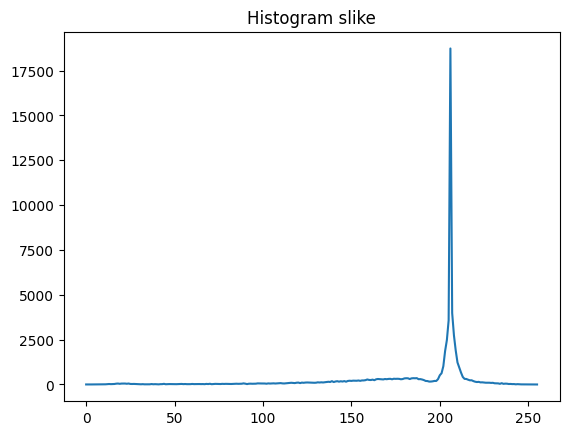

In [25]:
h = cv2.calcHist([im1], [0], None, [256], [0, 256])
print('Broj odmeraka u histogramu je', h.size)
plt.figure()
plt.plot(h)
plt.title('Histogram slike')
plt.show()

6.2. Napravit normalizovani histogram? Šta je normalizovani histogram? Prikazati ga.

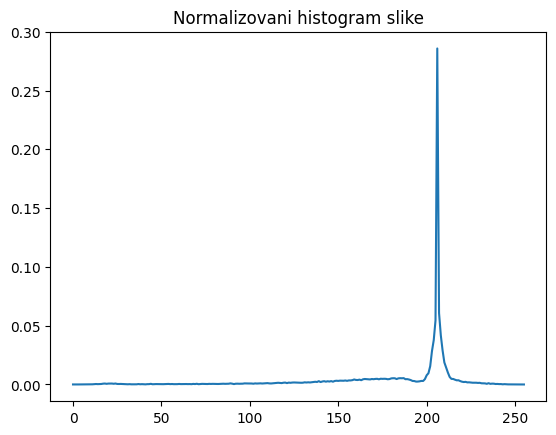

In [26]:
h_n = h/im1.size
plt.figure()
plt.plot(h_n)
plt.title('Normalizovani histogram slike')
plt.show()


6.3. Koliki udeo (%) slike im1 ima vrednost 206?

In [27]:
udeo206 = h_n[206]
print(round(udeo206[0]*100, 2), '% slike ima vrednost 206')

28.58 % slike ima vrednost 206


6.4. Koliki udeo (%) slike im1 ima vrednost ispod 200?

In [28]:
udeo_do_200 = sum(h_n[:200])
print(round(udeo_do_200[0]*100, 2), '% slike ima vrednost ispod 200')

32.77 % slike ima vrednost ispod 200


### 7. Osnovne manipulacije nad DICOM fajlovima

In [29]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.5 MB/s eta 0:00:00


In [30]:
import pydicom as dicom
import matplotlib.pyplot as plt

7.1. Učitati fajl 00044.dcm u promenljivu dc i ispisati je na ekranu. Analizirati kako su predstavljeni podaci.

In [31]:
!gdown "https://drive.google.com/uc?id=1kBEagv28ltEk3QWM4EKcB_FW0zuVlIDq"

Downloading...
From: https://drive.google.com/uc?id=1kBEagv28ltEk3QWM4EKcB_FW0zuVlIDq
To: /content/BMI_OSuM/00044.dcm
100% 100k/100k [00:00<00:00, 61.1MB/s]


In [32]:
dc = dicom.dcmread('00044.dcm') # ukoliko se fajl nalazi u drugom folderu ovde staviti putanju do njega
print(dc)
print()

/usr/local/lib/python3.12/dist-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '1.2.826.0.1.3680043.8.1055.1.20111102150801856.09856324.62601018'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 230
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.826.0.1.3680043.8.1055.1.20111102150801856.09856324.62601018
(0002,0010) Transfer Syntax UID                 UI: JPEG 2000 Image Compression
(0002,0012) Implementation Class UID            UI: 1.2.826.0.1.3680043.8.1055.1
(0002,0013) Implementation Version Name         SH: 'dicomlibrary-100'
(0002,0016) Source Application Entity Title     AE: 'DICOMLIBRARY'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'HELIX']
(0008,0012) Instance Creation Date              DA: '20061012'
(0008,0013) Instance Creation Time              TM: '091616.000000'
(0008

/usr/local/lib/python3.12/dist-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '1.2.826.0.1.3680043.8.1055.1.20111102150758591.96842950.07877442'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


7.2. Izbrisati atribut PatientID iz promenljive dc.

In [33]:
del dc.PatientID

7.3. Anonimizovati DICOM fajl tako što ćete zameniti PatientName praznim stringom i dodati proizvoljni PatientID. Sačuvati ove izmene u 00044_1.dcm


In [34]:
dc.PatientName = ''
dc.PatientID = '000123_123'
dc.save_as('00044_1.dcm')

7.4. Pristupiti atributu PatientID pomoću njegovor taga [0x0010, 0x0020].

In [35]:
print(dc[0x0010, 0x0020])

(0010,0020) Patient ID                          LO: '000123_123'


7.5. Iz DICOM fajla izvući sliku u promenljivu im. Prikazati sliku vodeći računa o granicama dinamičkog opsega. Koji modalitet snimanja je u pitanju? Proveriti pretpostavku analizom atributa Modality u promenljivoj dc (tag [0x0008, 0x0060]).

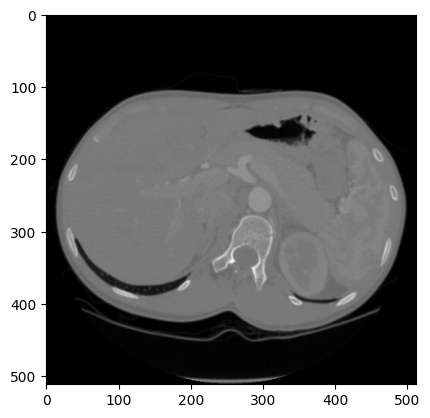


(0008,0060) Modality                            CS: 'CT'


In [36]:
im = dc.pixel_array
plt.figure(1)
plt.imshow(im, cmap='gray', vmin=im.min(), vmax=im.max())
plt.show()
print()
print(dc[0x0008, 0x0060])

## Manipulacije nad 3D slikom

In [37]:
!pip install pydicom

In [38]:
import pydicom as dicom

import numpy as np
import cv2

from google.colab.patches import cv2_imshow
from IPython.display import clear_output
from time import sleep
from ipywidgets import interact, interactive

%matplotlib inline

### 1. Video iz DICOM fajla

1.1. Učitati DICOM fajl 0002.dcm i u posebnu promenljivu izvući atribut koji se odnosi na snimak, tj. sekvencu snimaka u ovom primeru. Koje su dimenzije te promenljive? Koji je modalitet snimanja u pitanju?

In [39]:
!gdown "https://drive.google.com/uc?id=1JXIwzbAU_wMDPPaqewThcc3cfJEeDy1y"

Downloading...
From: https://drive.google.com/uc?id=1JXIwzbAU_wMDPPaqewThcc3cfJEeDy1y
To: /content/BMI_OSuM/0002.DCM
100% 1.70M/1.70M [00:00<00:00, 83.3MB/s]


In [40]:
pd = dicom.dcmread('0002.DCM')
im = pd.pixel_array

1.2. Reorganizovati redosled dimenzija tako da se dimenzija koja se odnosi na vreme nalazi na poslednjem mestu. (Ovaj korak nije neophodan.)

In [41]:
im = np.swapaxes(im, 0, 1)
im = np.swapaxes(im, 1, 2)

1.3. Sačuvati učitanu angiografsku sekvencu u video fajl videoXA.avi.

In [42]:
fourcc = cv2.VideoWriter_fourcc('M', 'J', 'P', 'G')
fps = 10  # frame rate
frame_size = (im.shape[0], im.shape[1])  # dimeznije frejma; ako je izostavljen korak 1.2 prilagoditi ovaj deo
isColour = 0

# Video Writer objekat
video_out = cv2.VideoWriter('videoXA.avi', fourcc, fps, frame_size, isColour)

# zapisivanje frejm po frejm
for i in range(im.shape[2]):
    video_out.write(im[:, :, i])

video_out.release()

1.4. Prikazati video napravljen u prethodnom koraku.

In [ ]:
from moviepy.editor import *
path="videoXA.avi"

clip=VideoFileClip(path)
clip.ipython_display(width=280)

### 2. Učitavanje 3D slike

2.1. Napraviti novi modul slika_3d.py i u njemu funkciju imread_3d za učitavanje 3D slike u formatu .img sa propratnih .hdr fajlom.

In [44]:
import numpy as np

def imread_3d(img_path, hdr_path):
    f_img = open(img_path, 'rb')
    f_hdr = open(hdr_path, 'rb')

    img = np.fromfile(f_img, np.dtype('uint16'))
    f_hdr.seek(40)  # postavljanje pointera na zeljenu lokaciju
    hdr = np.fromfile(f_hdr, np.dtype('uint16'))

    ndims = hdr[0]
    im_dims = hdr[1:ndims + 1]
    image = img.reshape(im_dims)

    f_img.close()
    f_hdr.close()

    return image

2.2. U glavnom modulu učitati sliku iz fajlova 01006_t1_cma.img i 01006_t1_cma.hdr. Kojih dimenzija je ova slika?

In [45]:
import sys
sys.path.append('/content/BMI_OSuM/utils')
import slika_3d

In [46]:
!gdown "https://drive.google.com/uc?id=1bD6kumbV7jNoLxULSHrsU8D-0y5OdSfw"
!gdown "https://drive.google.com/uc?id=1HManYxv085iwo0DUYXw4BBsiEarA1fAm"

Downloading...
From: https://drive.google.com/uc?id=1bD6kumbV7jNoLxULSHrsU8D-0y5OdSfw
To: /content/BMI_OSuM/01006_t1_cma.hdr
100% 348/348 [00:00<00:00, 1.43MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1HManYxv085iwo0DUYXw4BBsiEarA1fAm
From (redirected): https://drive.google.com/uc?id=1HManYxv085iwo0DUYXw4BBsiEarA1fAm&confirm=t&uuid=d6b26c42-c0f2-41a0-863f-f85c5dff9628
To: /content/BMI_OSuM/01006_t1_cma.img
100% 16.8M/16.8M [00:00<00:00, 263MB/s]


In [47]:
im = slika_3d.imread_3d('01006_t1_cma.img', '01006_t1_cma.hdr')
im = im.astype(np.uint8)

2.3. Prikazati presek ove 3D slike u xy ravni, za z=100. Obratiti pažnju da je redosled dimenzija (z,x,y). Koji modalitet snimanja je u pitanju?

In [48]:
import matplotlib.pyplot as plt

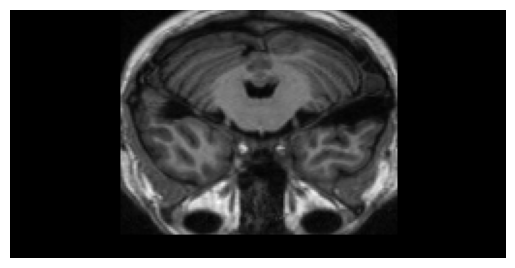

In [49]:
z = 100
im_z = im[z, :, :]
plt.figure(1)
plt.imshow(im_z, cmap='gray', vmin=im_z.min(), vmax=im_z.max())
plt.axis('off')
plt.show()

### 3. GUI za prikaz 3D slike u 3 projekcije

GUI za jedanu dimenziju (prikaz_z.py):

3.1. Prikazati presek 3D MRI slike u xy ravni na jednom subplot-u.

In [ ]:
def plot_zproj(z):
  im_z = im[z, :, :]
  plt.figure(1)
  plt.imshow(im_z, cmap='gray', vmin=im_z.min(), vmax=im_z.max())
  plt.axis('off')
  plt.show()

interactive_plot = interactive(plot_zproj,z=(0,im.shape[0]-1))
output = interactive_plot.children[-1]
interactive_plot

3.3. Definisati callback funkciju koja definiše akciju koja se dešava na promenu vrednosti slajdera. Pozvati tu funkciju.
GUI za 3 dimenzije:

Funkcija interactive to radi.
3.4. U modulu slika_3d.py napraviti funkciju imshow_slice koja prikazuje 3D sliku u sva tri preseka. U okviru nje definisati slajdere za promenu vrednosti preseka po svim dimenzijama.

3.5. U glavnom modulu definisati callback funkcije za sva tri preseka.

3.6. Iskoristiti matplotlib podmodul gridspec za organizaciju subplot-ova.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

im = slika_3d.imread_3d('01006_t1_cma.img', '01006_t1_cma.hdr')
im = im.astype(np.uint8)

def plot3d(z, x, y):
  fig = plt.figure()
  gs = fig.add_gridspec(2, 2)
  ax_z = fig.add_subplot(gs[0, 0])
  ax_x = fig.add_subplot(gs[1, 0])
  ax_y = fig.add_subplot(gs[:, 1])

  ax_z.imshow(im[z, :, :], cmap='gray', vmin=im[z, :, :].min(), vmax=im[z, :, :].max())
  ax_x.imshow(im[:, x, :], cmap='gray', vmin=im[:, x, :].min(), vmax=im[:, x, :].max())
  ax_y.imshow(im[:, :, y], cmap='gray', vmin=im[:, :, y].min(), vmax=im[:, :, y].max())
  plt.show()

interactive_plot = interactive(plot3d, z=(0,im.shape[0]-1),x=(0,im.shape[1]-1), y=(0, im.shape[2]-1))
output = interactive_plot.children[-1]
interactive_plot

### 4. Koordinate na kojima se nalazi sadržaj slike

4.1. Napraviti funkciju koordinate u modulu slika_3d.py koja pronalazi početnu i krajnju koordinatu na kojima se nalazi sadržaj slike. Očitati vrednosti koordinata na kojima počinje i na kojima se završava sadržaj slike, za sve tri dimenzije. Da li se očitane vrednosti slažu sa vrednostima koje su dobijene iz funkcije?


In [52]:
def koordinate(im, dim):
    c = 1
    # prolaz kroz svaki presek dimenzije dim
    for i in range(im.shape[dim]):
        if dim == 0:
            tmp = im[i, :, :]
        elif dim == 1:
            tmp = im[:, i, :]
        elif dim == 2:
            tmp = im[:, :, i]

        # ukoliko ima makar jedan piksel cija vrednost nije 0 - detektovan sadrzaj slike;
        if tmp.any() and c == 1:
            pocetak = i
            c = 2  # da se ne prebrise koordinata pocetka u sledecoj iteraciji

        # krajnja koordinata se trazi samo ako je vec pronadjen pocetak (c==2)
        if not tmp.any() and c == 2:
            kraj = i-1  # poslednja koordinata na kojoj se nalazio sadrzaj
            break

    return pocetak, kraj

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

im = slika_3d.imread_3d('01006_t1_cma.img', '01006_t1_cma.hdr')
im = im.astype(np.uint8)

def plot3d(z, x, y):
  fig = plt.figure()
  gs = fig.add_gridspec(2, 2)
  ax_z = fig.add_subplot(gs[0, 0])
  ax_x = fig.add_subplot(gs[1, 0])
  ax_y = fig.add_subplot(gs[:, 1])

  ax_z.imshow(im[z, :, :], cmap='gray', vmin=im[z, :, :].min(), vmax=im[z, :, :].max())
  ax_x.imshow(im[:, x, :], cmap='gray', vmin=im[:, x, :].min(), vmax=im[:, x, :].max())
  ax_y.imshow(im[:, :, y], cmap='gray', vmin=im[:, :, y].min(), vmax=im[:, :, y].max())
  plt.show()

interactive_plot = interactive(plot3d, z=(koordinate(im, 0)),x=(koordinate(im, 1)), y=(koordinate(im, 2)))
output = interactive_plot.children[-1]
interactive_plot